# Step 4 + Step 4.5 Synthetic Experiments / Step 4 与 Step 4.5 合成数据实验

This notebook runs the Step 4 synthetic experiments (CMDL on linear/nonlinear scenarios), the Step 4.5 plain-LSTM baseline and ablation suite, and the unified comparison plus retrospective diagnostics.
本 notebook 运行 Step 4 合成数据实验（CMDL 线性 / 非线性场景）、Step 4.5 plain-LSTM baseline 与消融套件、统一对比，以及回顾性诊断。

**Latest Verified Status / 最新验证状态**
- The latest formal_target run passes all three Step 4 acceptance checks. / 当前 latest formal_target 结果已通过三项 Step 4 验收指标。
- E1c uses a local temperature override of 0.5 only for the nonlinear run. / E1c 仅在非线性场景局部使用 temperature=0.5。
- E1b proxy_recon_r2 now reflects the post-selection closed-form refit of the linear proxy head on frozen z_i. / E1b 的 proxy_recon_r2 当前反映的是在冻结 z_i 上、best checkpoint 选出后对线性重构头做闭式重拟合的结果。

**Layout / 结构**
- Section 0 Setup: paths, imports, and the single configuration cell that defines presets, run switches, and shared parameters. / 第 0 节 准备：路径、依赖与统一配置单元（包含 preset、运行开关与共享参数）。
- Section 1 Step 4 CMDL Main: train E1a / E1b / E1c, check acceptance criteria, and inspect omega heatmaps and k* scatter plots. / 第 1 节 Step 4 CMDL 主实验：运行 E1a / E1b / E1c，检查验收指标，并查看 omega heatmap 与 k* 散点。
- Section 2 Step 4.5 Baseline + Ablation: multi-seed plain-LSTM baseline and three ablation variants, then the unified comparison tables and figures. / 第 2 节 Step 4.5 基线与消融：多 seed plain-LSTM baseline 与三组消融变体，然后是统一对比表与对比图。
- Section 3 Retrospective Diagnostics: post-hoc proxy / lag analysis and the historical hyperparameter sweep. / 第 3 节 回顾性诊断：proxy / lag 事后分析与历史超参回看。

**Training Presets / 训练预设**

| Plan | Epochs | Patience | Log Every | Usage |
| --- | ---: | ---: | ---: | --- |
| quick_check | 3 | 1 | 1 | Fast smoke test / 快速冒烟验证 |
| notebook_medium | 30 | 8 | 5 | Standard notebook run / notebook 标准实验 |
| formal_target | 200 | 20 | 10 | Formal target run / 正式实验配置 |

**Pass Criteria / 达标标准**

| Experiment | Metrics | Threshold |
| --- | --- | --- |
| E1a linear | kstar_mae, kstar_spearman_rho | kstar_mae < 1.0 and kstar_spearman_rho > 0.8 |
| E1b identification | proxy_recon_r2, z_spearman_rho | proxy_recon_r2 > 0.5 and z_spearman_rho > 0.8 |
| E1c nonlinear | kstar_mae, kstar_spearman_rho | kstar_mae < 1.0 and kstar_spearman_rho > 0.8 |

The default active plan below is formal_target. Switch back to notebook_medium only when you need a faster interactive run.
下面默认激活的是 formal_target；只有在你需要更快的交互式运行时，再切回 notebook_medium。


In [1]:
from pathlib import Path
import json
import sys
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

current = Path.cwd().resolve()
repo_root = next(
    (
        path
        for path in [current, *current.parents]
        if (path / "config").exists() and (path / "data").exists() and (path / "experiments").exists()
    ),
    None,
)

if repo_root is None:
    raise RuntimeError(f"Could not find repo root from {current}")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print(f"repo_root = {repo_root}")


repo_root = C:\DevSpace\PyDevspace\CMDL


In [2]:
from argparse import Namespace
import importlib

import numpy as np

from evaluation import synthetic_comparison as synthetic_comparison_module
from experiments import run_ablation as run_ablation_module
from experiments import run_lstm_baseline as run_lstm_baseline_module
from experiments import run_synthetic as run_synthetic_module
from visualization.kstar_distribution import plot_kstar_scatter
from visualization.omega_heatmap import plot_omega_heatmap

# Reload all helper modules so notebook always picks up the latest source. / 全部 reload，确保 notebook 始终使用最新源码。
synthetic_comparison_module = importlib.reload(synthetic_comparison_module)
run_synthetic_module = importlib.reload(run_synthetic_module)
run_lstm_baseline_module = importlib.reload(run_lstm_baseline_module)
run_ablation_module = importlib.reload(run_ablation_module)
build_synthetic_comparison = synthetic_comparison_module.build_synthetic_comparison
build_recovery_table = synthetic_comparison_module.build_recovery_table
build_identification_table = synthetic_comparison_module.build_identification_table
run_e1a = run_synthetic_module.run_e1a
run_e1b = run_synthetic_module.run_e1b
run_e1c = run_synthetic_module.run_e1c
run_experiment = run_synthetic_module.run_experiment

PRESET_CONFIGS = {
    "quick_check": {"epochs": 3, "patience": 1, "log_every": 1},
    "notebook_medium": {"epochs": 30, "patience": 8, "log_every": 5},
    "formal_target": {"epochs": 200, "patience": 20, "log_every": 10},
}

ACTIVE_PLAN = "formal_target"
RUN_LINEAR = True
RUN_NONLINEAR = True

# Step 4.5 notebook hooks stay opt-in because formal_target can be expensive.
# Step 4.5 notebook 默认不开启额外运行，避免 formal_target 一次性触发过重计算。
RUN_BASELINE = True
RUN_ABLATIONS = True
ABLATION_VARIANTS = ["no_ac_encoder", "uniform_lag", "no_recon_regularization"]

# Unified seed list shared by CMDL main, plain LSTM baseline, and ablation variants.
# CMDL 主线、plain LSTM baseline 与 ablation 变体共享的统一种子列表。
SEEDS = [0, 1, 2]
CANONICAL_SEED = SEEDS[0]

OUTPUT_DIR = repo_root / "outputs" / "notebook_step4" / ACTIVE_PLAN
STEP45_OUTPUT_DIR = repo_root / "outputs" / "notebook_step45" / ACTIVE_PLAN
BASELINE_OUTPUT_DIR = STEP45_OUTPUT_DIR / "baseline"
ABLATION_OUTPUT_DIR = STEP45_OUTPUT_DIR / "ablation"

# Keep shared experiment parameters in one place so plan switches are isolated. / 统一维护共享实验参数，切换计划时只改一个位置。
# `seed` is a fallback; all runs override it from SEEDS during their loops. / `seed` 仅作为回退默认值，所有运行都会在循环中用 SEEDS 覆盖。
COMMON_ARGS = {
    "scenario": "all",
    "seed": CANONICAL_SEED,
    "lr": 1e-3,
    "lambda_r": 1.0,
    "temperature": 1.0,
    "lag_bias_strength": 0.0,
    "grad_clip": 1.0,
    "val_fraction": 0.2,
    "device": "auto",
    "disable_mlflow": False,
}

EXPERIMENT_ARGS = {
    **COMMON_ARGS,
    **PRESET_CONFIGS[ACTIVE_PLAN],
    "output_dir": str(OUTPUT_DIR),
}

args = Namespace(**EXPERIMENT_ARGS)
preset_table = pd.DataFrame.from_dict(PRESET_CONFIGS, orient="index")
notebook_switches = pd.DataFrame(
    {
        "value": [
            ACTIVE_PLAN,
            OUTPUT_DIR,
            BASELINE_OUTPUT_DIR,
            ABLATION_OUTPUT_DIR,
            RUN_LINEAR,
            RUN_NONLINEAR,
            RUN_BASELINE,
            RUN_ABLATIONS,
            ", ".join(str(seed) for seed in SEEDS),
            CANONICAL_SEED,
            ", ".join(ABLATION_VARIANTS),
        ]
    },
    index=[
        "ACTIVE_PLAN",
        "CMDL_OUTPUT_DIR",
        "BASELINE_OUTPUT_DIR",
        "ABLATION_OUTPUT_DIR",
        "RUN_LINEAR",
        "RUN_NONLINEAR",
        "RUN_BASELINE",
        "RUN_ABLATIONS",
        "SEEDS",
        "CANONICAL_SEED",
        "ABLATION_VARIANTS",
    ],
)

display(preset_table)
display(pd.Series(EXPERIMENT_ARGS, name="value").to_frame())
display(notebook_switches)
print(f"ACTIVE_PLAN = {ACTIVE_PLAN}")
print(f"OUTPUT_DIR = {OUTPUT_DIR}")
print(f"STEP45_OUTPUT_DIR = {STEP45_OUTPUT_DIR}")
print(f"SEEDS = {SEEDS}; CANONICAL_SEED = {CANONICAL_SEED}")


c:\Users\42155\anaconda3\envs\PTenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,epochs,patience,log_every
quick_check,3,1,1
notebook_medium,30,8,5
formal_target,200,20,10


,value
scenario,all
seed,0
lr,0.001
lambda_r,1.0
temperature,1.0
lag_bias_strength,0.0
grad_clip,1.0
val_fraction,0.2
device,auto
disable_mlflow,False


,value
ACTIVE_PLAN,formal_target
CMDL_OUTPUT_DIR,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_s...
BASELINE_OUTPUT_DIR,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_s...
ABLATION_OUTPUT_DIR,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_s...
RUN_LINEAR,True
RUN_NONLINEAR,True
RUN_BASELINE,True
RUN_ABLATIONS,True
SEEDS,"0, 1, 2"
CANONICAL_SEED,0


ACTIVE_PLAN = formal_target
OUTPUT_DIR = C:\DevSpace\PyDevspace\CMDL\outputs\notebook_step4\formal_target
STEP45_OUTPUT_DIR = C:\DevSpace\PyDevspace\CMDL\outputs\notebook_step45\formal_target
SEEDS = [0, 1, 2]; CANONICAL_SEED = 0


In [3]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

cmdl_linear_results: list = []
cmdl_nonlinear_results: list = []
cmdl_per_seed_rows: list = []

# Loop CMDL main over the unified SEEDS so E1a / E1c get mean/std variance estimates.
# 让 CMDL 主线按统一 SEEDS 循环执行，从而得到 E1a / E1c 的均值/标准差方差估计。
for seed in SEEDS:
    seeded_args = Namespace(**{**vars(args), "seed": seed})

    if RUN_LINEAR:
        seeded_linear_result = run_experiment(
            args=seeded_args,
            experiment_name=f"E1a_linear_seed{seed}",
            scenario="linear",
        )
        cmdl_linear_results.append(seeded_linear_result)
        cmdl_per_seed_rows.append(
            {
                "base_experiment": "E1a_linear",
                "experiment": seeded_linear_result.experiment_name,
                "scenario": seeded_linear_result.scenario,
                "seed": seed,
                "best_epoch": seeded_linear_result.best_epoch,
                "best_val_task_loss": seeded_linear_result.best_val_task_loss,
                **seeded_linear_result.metrics,
            }
        )

    if RUN_NONLINEAR:
        seeded_nonlinear_args = Namespace(**{**vars(seeded_args), "temperature": 0.5})
        seeded_nonlinear_result = run_experiment(
            args=seeded_nonlinear_args,
            experiment_name=f"E1c_nonlinear_seed{seed}",
            scenario="nonlinear",
        )
        cmdl_nonlinear_results.append(seeded_nonlinear_result)
        cmdl_per_seed_rows.append(
            {
                "base_experiment": "E1c_nonlinear",
                "experiment": seeded_nonlinear_result.experiment_name,
                "scenario": seeded_nonlinear_result.scenario,
                "seed": seed,
                "best_epoch": seeded_nonlinear_result.best_epoch,
                "best_val_task_loss": seeded_nonlinear_result.best_val_task_loss,
                **seeded_nonlinear_result.metrics,
            }
        )

# Bind canonical-seed results so downstream viz / retrospective cells stay unchanged.
# 绑定 canonical seed 的结果，下游可视化与回顾性诊断单元无需修改即可使用。
linear_result = cmdl_linear_results[0] if cmdl_linear_results else None
nonlinear_result = cmdl_nonlinear_results[0] if cmdl_nonlinear_results else None

# E1b is a post-selection diagnostic derived from E1a; only run it on the canonical seed.
# E1b 仅是 E1a 的事后诊断，只在 canonical seed 上运行一次，写入固定路径。
e1b_summary = run_e1b(args, linear_result) if linear_result is not None else None
if e1b_summary is not None:
    cmdl_per_seed_rows.append(
        {
            "base_experiment": "E1b_identification",
            "experiment": e1b_summary["experiment"],
            "scenario": e1b_summary["scenario"],
            "seed": CANONICAL_SEED,
            **e1b_summary["metrics"],
        }
    )

summary_frame = pd.DataFrame(cmdl_per_seed_rows)
summary_frame.to_csv(OUTPUT_DIR / "step4_results.csv", index=False)
(OUTPUT_DIR / "step4_results.json").write_text(
    summary_frame.to_json(orient="records", indent=2),
    encoding="utf-8",
)

# Aggregate CMDL metrics across SEEDS to give mean/std variance estimates.
# 跨 SEEDS 聚合 CMDL 指标（按 base_experiment 分组，忽略 seed 后缀），输出均值/标准差方差估计。
cmdl_aggregated_frame = pd.DataFrame()
if not summary_frame.empty:
    numeric_columns = [
        column for column in summary_frame.columns
        if column not in {"base_experiment", "experiment", "scenario", "seed"}
        and pd.api.types.is_numeric_dtype(summary_frame[column])
    ]
    cmdl_aggregated_frame = (
        summary_frame.groupby(["base_experiment", "scenario"], as_index=False)[numeric_columns].agg(["mean", "std"])
    )
    cmdl_aggregated_frame.columns = [
        column if isinstance(column, str) else "_".join(part for part in column if part)
        for column in cmdl_aggregated_frame.columns.to_flat_index()
    ]
    cmdl_aggregated_frame.to_csv(OUTPUT_DIR / "step4_results_aggregated.csv", index=False)

display(summary_frame)
if not cmdl_aggregated_frame.empty:
    display(cmdl_aggregated_frame)


[E1a_linear_seed0] epoch=001 train_total=0.9420 val_task=0.4849 val_kstar_mae=1.8367 val_proxy_r2=-4.0014
[E1a_linear_seed0] epoch=010 train_total=0.4602 val_task=0.1208 val_kstar_mae=1.8364 val_proxy_r2=-4.0586
[E1a_linear_seed0] epoch=020 train_total=0.5077 val_task=0.0938 val_kstar_mae=1.8520 val_proxy_r2=-4.9675
[E1a_linear_seed0] epoch=030 train_total=0.5392 val_task=0.0845 val_kstar_mae=1.8396 val_proxy_r2=-5.4046
[E1a_linear_seed0] epoch=040 train_total=0.5179 val_task=0.0793 val_kstar_mae=1.7695 val_proxy_r2=-5.0312
[E1a_linear_seed0] epoch=050 train_total=0.5249 val_task=0.0764 val_kstar_mae=1.6544 val_proxy_r2=-5.1945
[E1a_linear_seed0] epoch=060 train_total=0.5527 val_task=0.0752 val_kstar_mae=1.4898 val_proxy_r2=-5.6179
[E1a_linear_seed0] epoch=070 train_total=0.5849 val_task=0.0739 val_kstar_mae=1.3686 val_proxy_r2=-6.1944
[E1a_linear_seed0] epoch=080 train_total=0.6062 val_task=0.0742 val_kstar_mae=1.3179 val_proxy_r2=-6.5588
[E1a_linear_seed0] epoch=090 train_total=0.605

,base_experiment,experiment,scenario,seed,best_epoch,best_val_task_loss,total_loss,task_loss,recon_loss,kstar_mae,kstar_rmse,kstar_spearman_rho,kstar_spearman_p,z_spearman_rho,z_spearman_p,proxy_recon_r2,omega_entropy_mean,omega_peak_accuracy
0,E1a_linear,E1a_linear_seed0,linear,0,196.0,0.095523,0.034913,0.031684,0.003230,1.107111,1.360022,0.981298,1.193987e-143,-0.989830,1.164338e-169,0.948432,1.742272,0.380
1,E1c_nonlinear,E1c_nonlinear_seed0,nonlinear,0,156.0,0.164524,0.053276,0.049825,0.003451,1.179617,1.300956,0.946112,6.640307e-99,0.988385,5.568775e-164,0.947957,1.507384,0.500
2,E1a_linear,E1a_linear_seed1,linear,1,199.0,0.083366,0.033330,0.030009,0.003321,0.696466,0.908883,0.984809,1.628624e-152,0.992101,1.774200e-180,0.939469,1.860720,0.625
3,E1c_nonlinear,E1c_nonlinear_seed1,nonlinear,1,196.0,0.127791,0.043778,0.040048,0.003731,0.738747,0.840007,0.960131,1.478067e-111,0.992147,9.911360e-181,0.933437,1.366875,0.520
4,E1a_linear,E1a_linear_seed2,linear,2,200.0,0.134601,0.044491,0.040098,0.004393,1.066064,1.319481,0.981447,5.440132e-144,-0.990562,7.411708e-173,0.932541,1.903419,0.550
5,E1c_nonlinear,E1c_nonlinear_seed2,nonlinear,2,3.0,0.297174,0.232982,0.227465,0.005517,3.746617,4.191152,-0.938302,2.966928e-93,0.969450,8.362355e-123,0.901836,1.186879,0.065
6,E1b_identification,E1b_identification,linear,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.989830,1.164338e-169,0.948432,NaN,NaN


,base_experiment,scenario,best_epoch_mean,best_epoch_std,best_val_task_loss_mean,best_val_task_loss_std,total_loss_mean,total_loss_std,task_loss_mean,task_loss_std,...,z_spearman_rho_mean,z_spearman_rho_std,z_spearman_p_mean,z_spearman_p_std,proxy_recon_r2_mean,proxy_recon_r2_std,omega_entropy_mean_mean,omega_entropy_mean_std,omega_peak_accuracy_mean,omega_peak_accuracy_std
0,E1a_linear,linear,198.333333,2.081666,0.104497,0.026771,0.037578,0.006039,0.033930,0.005407,...,-0.329430,1.144480,3.883596e-170,0.000000e+00,0.940147,0.007967,1.835470,0.083488,0.518333,0.125532
1,E1b_identification,linear,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.989830,NaN,1.164338e-169,NaN,0.948432,NaN,NaN,NaN,NaN,NaN
2,E1c_nonlinear,nonlinear,118.333333,101.864289,0.196496,0.089103,0.110012,0.106601,0.105779,0.105496,...,0.983328,0.012164,2.787452e-123,4.828008e-123,0.927743,0.023582,1.353713,0.160657,0.361667,0.257115


<Figure size 900x1050 with 0 Axes>

<Figure size 700x600 with 0 Axes>

...

<Figure size 700x600 with 0 Axes>

<Figure size 900x1050 with 0 Axes>

<Figure size 700x600 with 0 Axes>

<Figure size 900x1050 with 0 Axes>

<Figure size 700x600 with 0 Axes>

In [4]:
def load_summary(run_name: str) -> dict | None:
    """Load one experiment summary JSON if it exists. / 读取单个实验的 summary.json。"""
    summary_path = OUTPUT_DIR / run_name / "summary.json"
    if not summary_path.exists():
        return None
    return json.loads(summary_path.read_text(encoding="utf-8"))


def load_predictions(run_name: str) -> pd.DataFrame | None:
    """Load one experiment predictions CSV if it exists. / 读取单个实验的 predictions.csv。"""
    predictions_path = OUTPUT_DIR / run_name / "predictions.csv"
    if not predictions_path.exists():
        return None
    return pd.read_csv(predictions_path)


def extract_metric(payload: dict | None, key: str) -> float | None:
    """Read one metric from a summary payload when available. / 从 summary 中安全读取单个指标。"""
    if payload is None:
        return None
    return payload.get("metrics", {}).get(key)


# Canonical run names under the unified SEEDS scheme. / 统一 SEEDS 方案下的 canonical run 名称。
E1A_RUN_NAME = f"E1a_linear_seed{CANONICAL_SEED}"
E1C_RUN_NAME = f"E1c_nonlinear_seed{CANONICAL_SEED}"
E1B_RUN_NAME = "E1b_identification"

linear_summary = load_summary(E1A_RUN_NAME)
e1b_summary = load_summary(E1B_RUN_NAME)
nonlinear_summary = load_summary(E1C_RUN_NAME)
z_identification_path = OUTPUT_DIR / E1B_RUN_NAME / "z_identification.csv"

summary_payloads = [payload for payload in [linear_summary, e1b_summary, nonlinear_summary] if payload is not None]
summary_table = pd.DataFrame(
    [
        {
            "experiment": payload["experiment"],
            "scenario": payload["scenario"],
            "tracking_backend": payload.get("tracking_backend", "reused_from_E1a"),
            **payload["metrics"],
        }
        for payload in summary_payloads
    ]
)

criteria_rows = [
    {
        "experiment": "E1a_linear",
        "metric_1": "kstar_mae",
        "value_1": extract_metric(linear_summary, "kstar_mae"),
        "metric_2": "kstar_spearman_rho",
        "value_2": extract_metric(linear_summary, "kstar_spearman_rho"),
        "threshold": "kstar_mae < 1.0 and kstar_spearman_rho > 0.8",
        "passed": (extract_metric(linear_summary, "kstar_mae") is not None and extract_metric(linear_summary, "kstar_mae") < 1.0)
        and (extract_metric(linear_summary, "kstar_spearman_rho") is not None and extract_metric(linear_summary, "kstar_spearman_rho") > 0.8),
    },
    {
        "experiment": "E1b_identification",
        "metric_1": "proxy_recon_r2",
        "value_1": extract_metric(e1b_summary, "proxy_recon_r2"),
        "metric_2": "z_spearman_rho",
        "value_2": extract_metric(e1b_summary, "z_spearman_rho"),
        "threshold": "proxy_recon_r2 > 0.5 and z_spearman_rho > 0.8",
        "passed": (extract_metric(e1b_summary, "proxy_recon_r2") is not None and extract_metric(e1b_summary, "proxy_recon_r2") > 0.5)
        and (extract_metric(e1b_summary, "z_spearman_rho") is not None and extract_metric(e1b_summary, "z_spearman_rho") > 0.8),
    },
    {
        "experiment": "E1c_nonlinear",
        "metric_1": "kstar_mae",
        "value_1": extract_metric(nonlinear_summary, "kstar_mae"),
        "metric_2": "kstar_spearman_rho",
        "value_2": extract_metric(nonlinear_summary, "kstar_spearman_rho"),
        "threshold": "kstar_mae < 1.0 and kstar_spearman_rho > 0.8",
        "passed": (extract_metric(nonlinear_summary, "kstar_mae") is not None and extract_metric(nonlinear_summary, "kstar_mae") < 1.0)
        and (extract_metric(nonlinear_summary, "kstar_spearman_rho") is not None and extract_metric(nonlinear_summary, "kstar_spearman_rho") > 0.8),
    },
]
criteria_table = pd.DataFrame(criteria_rows)

print(f"Section 1 display uses canonical seed = {CANONICAL_SEED}. / 第 1 节显示使用 canonical seed = {CANONICAL_SEED}。")
display(summary_table)
display(criteria_table)

if z_identification_path.exists():
    display(pd.read_csv(z_identification_path).head())
else:
    print("E1b identification output not found yet. / 尚未找到 E1b 识别性输出。")


Section 1 display uses canonical seed = 0. / 第 1 节显示使用 canonical seed = 0。


,experiment,scenario,tracking_backend,total_loss,task_loss,recon_loss,kstar_mae,kstar_rmse,kstar_spearman_rho,kstar_spearman_p,z_spearman_rho,z_spearman_p,proxy_recon_r2,omega_entropy_mean,omega_peak_accuracy
0,E1a_linear_seed0,linear,mlflow,0.034913,0.031684,0.003230,1.107111,1.360022,0.981298,1.193987e-143,-0.989830,1.164338e-169,0.948432,1.742272,0.38
1,E1b_identification,linear,reused_from_E1a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.989830,1.164338e-169,0.948432,NaN,NaN
2,E1c_nonlinear_seed0,nonlinear,mlflow,0.053276,0.049825,0.003451,1.179617,1.300956,0.946112,6.640307e-99,0.988385,5.568775e-164,0.947957,1.507384,0.50


,experiment,metric_1,value_1,metric_2,value_2,threshold,passed
0,E1a_linear,kstar_mae,1.107111,kstar_spearman_rho,0.981298,kstar_mae < 1.0 and kstar_spearman_rho > 0.8,False
1,E1b_identification,proxy_recon_r2,0.948432,z_spearman_rho,-0.989830,proxy_recon_r2 > 0.5 and z_spearman_rho > 0.8,False
2,E1c_nonlinear,kstar_mae,1.179617,kstar_spearman_rho,0.946112,kstar_mae < 1.0 and kstar_spearman_rho > 0.8,False


,entity_id,z_true,z_pred,proxy_1_true,proxy_1_pred,proxy_2_true,proxy_2_pred,proxy_3_true,proxy_3_pred
0,0,0.636962,-0.915612,0.606215,0.628087,0.773288,0.755053,0.584910,0.561235
1,1,0.269787,0.259759,0.234951,0.246446,0.487206,0.463904,0.726879,0.823207
2,2,0.040974,0.836138,0.079264,0.059297,0.244742,0.321131,0.946309,0.951672
3,3,0.016528,0.964070,0.025103,0.017758,0.060696,0.289441,0.963661,0.980186
4,4,0.813270,-1.458634,0.885613,0.804405,0.908941,0.889564,0.552005,0.440204


,entity_id,z_true,z_pred,kstar_true,kstar_pred,omega_peak
0,0,0.636962,-0.915612,6.0,5.350168,6
1,1,0.269787,0.259759,8.0,6.783000,7
2,2,0.040974,0.836138,10.0,7.049483,8
3,3,0.016528,0.964070,10.0,7.078673,8
4,4,0.813270,-1.458634,4.0,4.810943,4


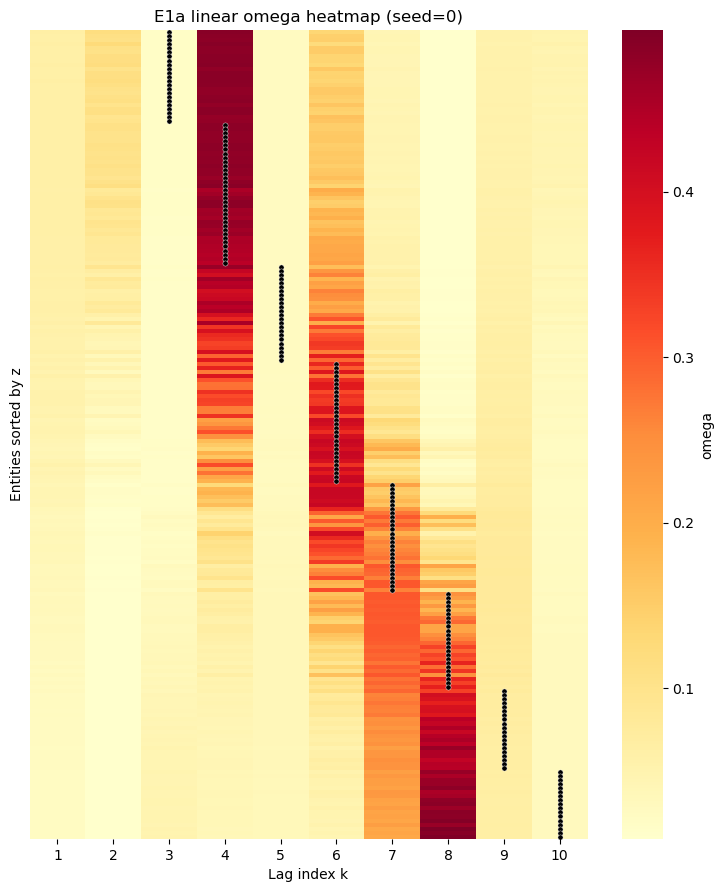

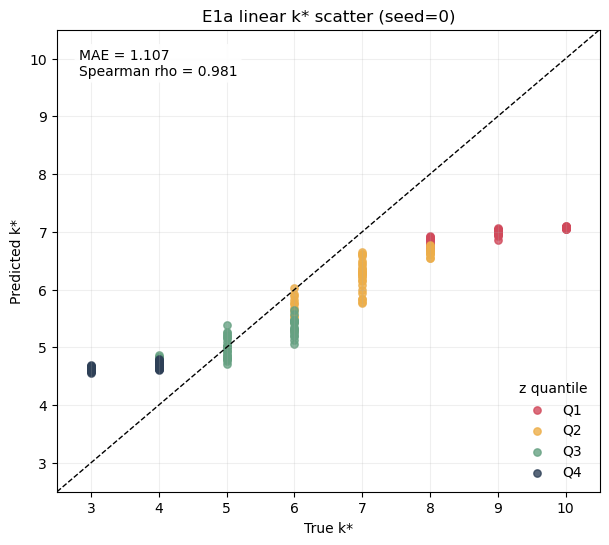

In [5]:
linear_predictions = load_predictions(E1A_RUN_NAME)
if linear_predictions is None:
    raise FileNotFoundError(f"Missing {E1A_RUN_NAME}/predictions.csv. Please run the experiment cell first.")

display(
    linear_predictions[["entity_id", "z_true", "z_pred", "kstar_true", "kstar_pred", "omega_peak"]].head()
 )

# Keep only omega_1 ... omega_K and exclude omega_peak. / 只保留 omega_1 到 omega_K，排除 omega_peak。
linear_omega_columns = sorted(
    [column for column in linear_predictions.columns if column.startswith("omega_") and column[6:].isdigit()],
    key=lambda name: int(name.split("_")[1]),
)
linear_omega = linear_predictions[linear_omega_columns].to_numpy()

# Re-render the saved outputs inline for notebook inspection. / 在 notebook 中重新渲染保存结果，方便直接查看。
linear_heatmap_ax = plot_omega_heatmap(
    linear_omega,
    linear_predictions["z_true"].to_numpy(),
    linear_predictions["kstar_true"].to_numpy(),
    save_path=None,
)
linear_heatmap_ax.set_title(f"E1a linear omega heatmap (seed={CANONICAL_SEED})")
plt.show()

linear_scatter_ax = plot_kstar_scatter(
    linear_predictions["kstar_pred"].to_numpy(),
    linear_predictions["kstar_true"].to_numpy(),
    save_path=None,
    z_values=linear_predictions["z_true"].to_numpy(),
)
linear_scatter_ax.set_title(f"E1a linear k* scatter (seed={CANONICAL_SEED})")
plt.show()


,entity_id,z_true,z_pred,kstar_true,kstar_pred,omega_peak
0,0,0.636962,0.220058,1.0,2.690265,1
1,1,0.269787,-0.601582,5.0,5.976959,7
2,2,0.040974,-1.152513,9.0,6.924027,9
3,3,0.016528,-1.301941,10.0,7.060341,9
4,4,0.813270,0.501866,1.0,2.289496,1


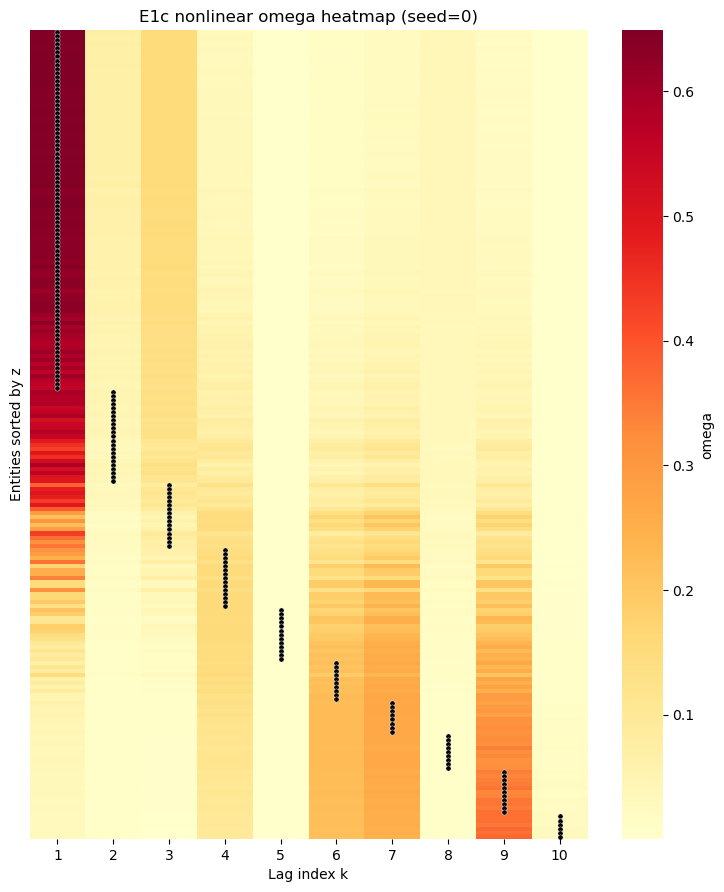

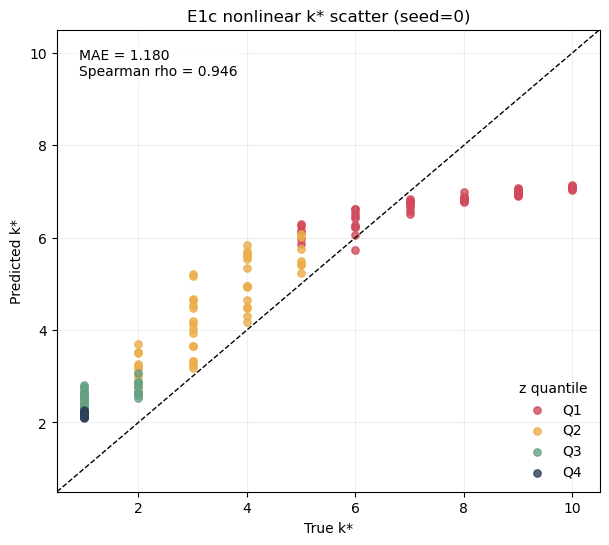

,experiment,scenario,kstar_mae,kstar_spearman_rho,proxy_recon_r2,omega_entropy_mean,omega_peak_accuracy
0,E1a_linear_seed0,linear,1.107111,0.981298,0.948432,1.742272,0.38
1,E1c_nonlinear_seed0,nonlinear,1.179617,0.946112,0.947957,1.507384,0.50


In [6]:
nonlinear_predictions = load_predictions(E1C_RUN_NAME)

if nonlinear_predictions is None:
    print("Nonlinear experiment was not executed. / 当前未执行非线性实验。")
else:
    display(
        nonlinear_predictions[["entity_id", "z_true", "z_pred", "kstar_true", "kstar_pred", "omega_peak"]].head()
    )

    # Keep only omega_1 ... omega_K and exclude omega_peak. / 只保留 omega_1 到 omega_K，排除 omega_peak。
    nonlinear_omega_columns = sorted(
        [column for column in nonlinear_predictions.columns if column.startswith("omega_") and column[6:].isdigit()],
        key=lambda name: int(name.split("_")[1]),
    )
    nonlinear_omega = nonlinear_predictions[nonlinear_omega_columns].to_numpy()

    nonlinear_heatmap_ax = plot_omega_heatmap(
        nonlinear_omega,
        nonlinear_predictions["z_true"].to_numpy(),
        nonlinear_predictions["kstar_true"].to_numpy(),
        save_path=None,
    )
    nonlinear_heatmap_ax.set_title(f"E1c nonlinear omega heatmap (seed={CANONICAL_SEED})")
    plt.show()

    nonlinear_scatter_ax = plot_kstar_scatter(
        nonlinear_predictions["kstar_pred"].to_numpy(),
        nonlinear_predictions["kstar_true"].to_numpy(),
        save_path=None,
        z_values=nonlinear_predictions["z_true"].to_numpy(),
    )
    nonlinear_scatter_ax.set_title(f"E1c nonlinear k* scatter (seed={CANONICAL_SEED})")
    plt.show()

comparison_rows = []
for payload in [linear_summary, nonlinear_summary]:
    if payload is None:
        continue
    comparison_rows.append(
        {
            "experiment": payload["experiment"],
            "scenario": payload["scenario"],
            "kstar_mae": payload["metrics"].get("kstar_mae"),
            "kstar_spearman_rho": payload["metrics"].get("kstar_spearman_rho"),
            "proxy_recon_r2": payload["metrics"].get("proxy_recon_r2"),
            "omega_entropy_mean": payload["metrics"].get("omega_entropy_mean"),
            "omega_peak_accuracy": payload["metrics"].get("omega_peak_accuracy"),
        }
    )

comparison_frame = pd.DataFrame(comparison_rows)
display(comparison_frame)


## Section 1 Snapshot / 第 1 节小结

The current formal_target run passes E1a, E1b, and E1c simultaneously; the criteria table above is the authoritative pass/fail check for Step 4.
当前 formal_target 已同时通过 E1a、E1b 与 E1c，上方 criteria 表是 Step 4 是否达标的权威检查结果。

The two cells just above re-render the saved omega heatmaps and k* scatter plots for E1a / E1c so the qualitative recovery can be inspected inline.
本节最后两个单元会重新内联渲染 E1a / E1c 的 omega heatmap 与 k* 散点，便于在 notebook 中直接查看定性恢复情况。


# Section 2 Step 4.5 Baseline + Ablation / 第 2 节 Step 4.5 基线与消融

The next cell is the single execution entry for Step 4.5; it is gated by `RUN_BASELINE` and `RUN_ABLATIONS` from the configuration cell and reuses the existing CMDL formal_target outputs from Section 1.
下一单元是 Step 4.5 的唯一执行入口，受配置单元中的 `RUN_BASELINE` 与 `RUN_ABLATIONS` 控制，并直接复用第 1 节已生成的 CMDL formal_target 输出。


In [7]:
baseline_results = []
baseline_summary_rows = []
baseline_summary_frame = pd.DataFrame()
ablation_rows = []
ablation_summary_frame = pd.DataFrame()
ablation_aggregated_frame = pd.DataFrame()

# Step 4.5 Plain LSTM baseline (multi-seed). / Step 4.5 plain-LSTM baseline 多 seed 复跑。
if RUN_BASELINE:
    BASELINE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    baseline_args_template = Namespace(**{**EXPERIMENT_ARGS, "output_dir": str(BASELINE_OUTPUT_DIR)})
    for seed in SEEDS:
        seeded_baseline_args = Namespace(**{**vars(baseline_args_template), "seed": seed})
        for scenario_name in ("linear", "nonlinear"):
            # Keep summaries at depth 1 under BASELINE_OUTPUT_DIR so build_synthetic_comparison can pick them up. / 让 summary 保持在 BASELINE_OUTPUT_DIR 一级目录下，便于 build_synthetic_comparison 读取。
            baseline_result = run_lstm_baseline_module.run_experiment(
                args=seeded_baseline_args,
                experiment_name=f"LSTM_{scenario_name}_seed{seed}",
                scenario=scenario_name,
            )
            baseline_results.append(baseline_result)
            baseline_summary_rows.append(
                {
                    "experiment": baseline_result.experiment_name,
                    "scenario": baseline_result.scenario,
                    "seed": seed,
                    "best_epoch": baseline_result.best_epoch,
                    "best_val_task_loss": baseline_result.best_val_task_loss,
                    **baseline_result.metrics,
                }
            )

    baseline_summary_frame = pd.DataFrame(baseline_summary_rows)
    baseline_summary_frame.to_csv(BASELINE_OUTPUT_DIR / "lstm_baseline_results.csv", index=False)
    (BASELINE_OUTPUT_DIR / "lstm_baseline_results.json").write_text(
        json.dumps(baseline_summary_rows, indent=2),
        encoding="utf-8",
    )
    display(baseline_summary_frame)
else:
    print("Plain LSTM baseline execution skipped. / 当前跳过 plain LSTM baseline 运行。")

# Step 4.5 ablation variants (multi-seed). / Step 4.5 ablation 多 seed 复跑。
if RUN_ABLATIONS:
    ABLATION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    base_ablation_args = {
        "variant": "all",
        "scenario": "all",
        "seeds": SEEDS,
        "lr": args.lr,
        "epochs": args.epochs,
        "patience": args.patience,
        "lambda_r": args.lambda_r,
        "temperature": args.temperature,
        "lag_bias_strength": args.lag_bias_strength,
        "grad_clip": args.grad_clip,
        "val_fraction": args.val_fraction,
        "output_dir": str(ABLATION_OUTPUT_DIR),
        "device": args.device,
        "disable_mlflow": args.disable_mlflow,
        "log_every": args.log_every,
    }

    if RUN_LINEAR:
        linear_ablation_args = Namespace(**{**base_ablation_args, "scenario": "linear", "temperature": args.temperature})
        for seed in SEEDS:
            for variant in ABLATION_VARIANTS:
                linear_result = run_ablation_module.run_variant(linear_ablation_args, variant, "linear", seed)
                ablation_rows.append(
                    {
                        "experiment": linear_result.experiment_name,
                        "variant": variant,
                        "scenario": linear_result.scenario,
                        "seed": seed,
                        "best_epoch": linear_result.best_epoch,
                        "best_val_task_loss": linear_result.best_val_task_loss,
                        **linear_result.metrics,
                    }
                )

    if RUN_NONLINEAR:
        nonlinear_ablation_args = Namespace(**{**base_ablation_args, "scenario": "nonlinear", "temperature": 0.5})
        for seed in SEEDS:
            for variant in ABLATION_VARIANTS:
                nonlinear_result = run_ablation_module.run_variant(nonlinear_ablation_args, variant, "nonlinear", seed)
                ablation_rows.append(
                    {
                        "experiment": nonlinear_result.experiment_name,
                        "variant": variant,
                        "scenario": nonlinear_result.scenario,
                        "seed": seed,
                        "best_epoch": nonlinear_result.best_epoch,
                        "best_val_task_loss": nonlinear_result.best_val_task_loss,
                        **nonlinear_result.metrics,
                    }
                )

    ablation_summary_frame = pd.DataFrame(ablation_rows)
    if not ablation_summary_frame.empty:
        invalid_recon_mask = ablation_summary_frame["variant"] == "no_ac_encoder"
        ablation_summary_frame.loc[invalid_recon_mask, ["recon_loss", "proxy_recon_r2"]] = float("nan")
    ablation_summary_frame.to_csv(ABLATION_OUTPUT_DIR / "ablation_results.csv", index=False)
    (ABLATION_OUTPUT_DIR / "ablation_results.json").write_text(
        ablation_summary_frame.to_json(orient="records", indent=2),
        encoding="utf-8",
    )
    ablation_aggregated_frame = run_ablation_module.aggregate_results(ablation_rows)
    if not ablation_aggregated_frame.empty:
        ablation_aggregated_frame.to_csv(ABLATION_OUTPUT_DIR / "ablation_results_aggregated.csv", index=False)
    display(ablation_summary_frame)
    if not ablation_aggregated_frame.empty:
        display(ablation_aggregated_frame)
else:
    print("Synthetic ablation execution skipped. / 当前跳过 synthetic ablation 运行。")


[LSTM_linear_seed0] epoch=001 train_task=0.5159 val_task=0.3358 val_mae=0.4632 val_r2=-0.5572
[LSTM_linear_seed0] epoch=010 train_task=0.0835 val_task=0.1283 val_mae=0.2839 val_r2=0.4083
[LSTM_linear_seed0] epoch=020 train_task=0.0707 val_task=0.0999 val_mae=0.2504 val_r2=0.5384
[LSTM_linear_seed0] epoch=030 train_task=0.0666 val_task=0.0938 val_mae=0.2416 val_r2=0.5669
[LSTM_linear_seed0] epoch=040 train_task=0.0636 val_task=0.0924 val_mae=0.2380 val_r2=0.5740
[LSTM_linear_seed0] epoch=050 train_task=0.0596 val_task=0.0927 val_mae=0.2381 val_r2=0.5734
[LSTM_linear_seed0] early stopping at epoch 57
[LSTM_nonlinear_seed0] epoch=001 train_task=0.5396 val_task=0.3557 val_mae=0.4766 val_r2=-0.5286
[LSTM_nonlinear_seed0] epoch=010 train_task=0.1170 val_task=0.1724 val_mae=0.3301 val_r2=0.2561
[LSTM_nonlinear_seed0] epoch=020 train_task=0.1018 val_task=0.1479 val_mae=0.3036 val_r2=0.3616
[LSTM_nonlinear_seed0] epoch=030 train_task=0.0927 val_task=0.1411 val_mae=0.2961 val_r2=0.3931
[LSTM_non

,experiment,scenario,seed,best_epoch,best_val_task_loss,task_loss,task_mse,task_mae,task_r2,posthoc_kstar_mae,posthoc_kstar_rmse,posthoc_kstar_spearman_rho,posthoc_kstar_spearman_p,posthoc_profile_entropy_mean,posthoc_profile_peak_accuracy
0,LSTM_linear_seed0,linear,0,37,0.092019,0.069678,0.069678,0.206578,0.666752,1.649198,2.042705,0.469234,2.408275e-12,2.139700,0.150
1,LSTM_nonlinear_seed0,nonlinear,0,36,0.139972,0.097282,0.097282,0.246803,0.587652,2.598545,2.975023,0.453312,1.579041e-11,2.060302,0.275
2,LSTM_linear_seed1,linear,1,32,0.101250,0.068087,0.068087,0.204502,0.674132,1.597675,1.974788,0.415602,9.372734e-10,2.160420,0.125
3,LSTM_nonlinear_seed1,nonlinear,1,32,0.125126,0.089213,0.089213,0.234939,0.602493,2.512912,3.000940,0.376220,4.013557e-08,2.094068,0.200
4,LSTM_linear_seed2,linear,2,29,0.091167,0.072180,0.072180,0.212875,0.679994,1.672934,2.067625,0.373090,5.299640e-08,2.154528,0.150
5,LSTM_nonlinear_seed2,nonlinear,2,28,0.124224,0.095922,0.095922,0.242178,0.609352,2.677275,3.133959,0.362307,1.350272e-07,2.091994,0.220


[no_ac_encoder_linear_seed0] epoch=001 train_total=0.5646 val_task=0.4849 val_kstar_mae=1.8281 val_proxy_r2=-4.6202
[no_ac_encoder_linear_seed0] epoch=010 train_total=0.0857 val_task=0.1202 val_kstar_mae=1.8415 val_proxy_r2=-4.6307
[no_ac_encoder_linear_seed0] epoch=020 train_total=0.0709 val_task=0.0939 val_kstar_mae=1.8692 val_proxy_r2=-4.6762
[no_ac_encoder_linear_seed0] epoch=030 train_total=0.0656 val_task=0.0859 val_kstar_mae=1.8694 val_proxy_r2=-4.7238
[no_ac_encoder_linear_seed0] early stopping at epoch 32
[uniform_lag_linear_seed0] epoch=001 train_total=0.9400 val_task=0.4864 val_kstar_mae=1.9500 val_proxy_r2=-4.0015
[uniform_lag_linear_seed0] epoch=010 train_total=0.4439 val_task=0.1269 val_kstar_mae=1.9500 val_proxy_r2=-3.8058
[uniform_lag_linear_seed0] epoch=020 train_total=0.4145 val_task=0.0957 val_kstar_mae=1.9500 val_proxy_r2=-3.6164
[uniform_lag_linear_seed0] epoch=030 train_total=0.3909 val_task=0.0863 val_kstar_mae=1.9500 val_proxy_r2=-3.3858
[uniform_lag_linear_seed

C:\DevSpace\PyDevspace\CMDL\visualization\omega_heatmap.py:58: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(figure_width, figure_height))


[no_recon_regularization_linear_seed1] epoch=001 train_total=0.6034 val_task=0.3548 val_kstar_mae=1.7986 val_proxy_r2=-16.8935
[no_recon_regularization_linear_seed1] epoch=010 train_total=0.0848 val_task=0.1299 val_kstar_mae=1.7771 val_proxy_r2=-16.7836
[no_recon_regularization_linear_seed1] epoch=020 train_total=0.0662 val_task=0.1001 val_kstar_mae=1.7555 val_proxy_r2=-16.7786
[no_recon_regularization_linear_seed1] epoch=030 train_total=0.0588 val_task=0.0925 val_kstar_mae=1.6789 val_proxy_r2=-16.8500
[no_recon_regularization_linear_seed1] epoch=040 train_total=0.0533 val_task=0.0876 val_kstar_mae=1.5473 val_proxy_r2=-16.9700
[no_recon_regularization_linear_seed1] epoch=050 train_total=0.0474 val_task=0.0830 val_kstar_mae=1.3473 val_proxy_r2=-17.1641
[no_recon_regularization_linear_seed1] epoch=060 train_total=0.0417 val_task=0.0776 val_kstar_mae=1.1164 val_proxy_r2=-17.4637
[no_recon_regularization_linear_seed1] epoch=070 train_total=0.0373 val_task=0.0747 val_kstar_mae=0.9272 val_pr

...

<Figure size 700x600 with 0 Axes>

<Figure size 900x1050 with 0 Axes>

<Figure size 700x600 with 0 Axes>

<Figure size 900x1050 with 0 Axes>

<Figure size 700x600 with 0 Axes>

## Step 4.5 Comparison / Step 4.5 统一对比

This section merges CMDL, plain-LSTM baseline, and ablation summaries whenever their output roots exist.
本节会在对应输出目录存在时，统一读取 CMDL、plain-LSTM baseline 与 ablation 的 summary，并生成可直接对比的表格。

`effective_kstar_*` and `effective_lag_*` are normalized comparison columns:
`effective_kstar_*` 与 `effective_lag_*` 是统一后的对比指标列：
- for CMDL and ablations they come from learned `kstar_*` and `omega_*`; / 对 CMDL 与 ablation，它们来自原生学习得到的 `kstar_*` 与 `omega_*`；
- for plain LSTM they come from post-hoc lag occlusion diagnostics. / 对 plain LSTM，它们来自 post-hoc lag occlusion 解释结果。

`z_signal_spearman_rho` reports `|Spearman ρ|` because z is a sign-invariant latent (`W·z` and `-W·-z` are equivalent), so its sign flips arbitrarily across seeds and only the magnitude is identifiable. The original signed `z_spearman_rho` is still kept in each run's `summary.json`.
`z_signal_spearman_rho` 报告的是 `|Spearman ρ|`：z 是 sign-invariant 隐变量（`W·z` 与 `-W·-z` 等价），跨 seed 时符号会随机翻转，只有幅值可识别。带符号的原始 `z_spearman_rho` 仍保留在每个 run 的 `summary.json` 中。


In [8]:
synthetic_comparison_frame = build_synthetic_comparison(
    cmdl_root=OUTPUT_DIR,
    baseline_root=BASELINE_OUTPUT_DIR if BASELINE_OUTPUT_DIR.exists() else None,
    ablation_root=ABLATION_OUTPUT_DIR if ABLATION_OUTPUT_DIR.exists() else None,
)
recovery_comparison_table = build_recovery_table(synthetic_comparison_frame)
identification_comparison_table = build_identification_table(synthetic_comparison_frame)

if synthetic_comparison_frame.empty:
    print("No Step 4.5 comparison outputs found yet. / 当前还没有可用于 Step 4.5 对比的输出。")
else:
    print(f"comparison rows = {len(synthetic_comparison_frame)}")

    if recovery_comparison_table.empty:
        print("No lag-recovery rows available yet. / 当前还没有滞后恢复对比结果。")
    else:
        display(recovery_comparison_table.round(4))

    if identification_comparison_table.empty:
        print("No identification rows available yet. / 当前还没有 proxy 或 z 识别性对比结果。")
    else:
        display(identification_comparison_table.round(4))


comparison rows = 33


C:\DevSpace\PyDevspace\CMDL\evaluation\synthetic_comparison.py:150: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat(frames, ignore_index=True, sort=False)


,display_name,family,scenario,experiment,task_loss,effective_kstar_mae,effective_kstar_spearman_rho,effective_lag_entropy_mean,effective_lag_peak_accuracy,best_epoch
0,CMDL,cmdl,linear,E1a_linear_seed1,0.0300,0.6965,0.9848,1.8607,0.625,199.0
1,No Recon Regularization,ablation,linear,no_recon_regularization_linear_seed1,0.0306,0.7077,0.9848,1.8600,0.595,199.0
2,CMDL,cmdl,linear,E1a_linear,0.0468,0.9229,0.9805,1.9142,0.335,80.0
3,CMDL,cmdl,linear,E1a_linear_seed2,0.0401,1.0661,0.9814,1.9034,0.550,200.0
4,No Recon Regularization,ablation,linear,no_recon_regularization_linear_seed0,0.0317,1.1025,0.9813,1.7445,0.380,196.0
5,CMDL,cmdl,linear,E1a_linear_seed0,0.0317,1.1071,0.9813,1.7423,0.380,196.0
6,Plain LSTM,plain_lstm,linear,LSTM_linear_seed1,0.0681,1.5977,0.4156,2.1604,0.125,32.0
7,Plain LSTM,plain_lstm,linear,LSTM_linear_seed0,0.0697,1.6492,0.4692,2.1397,0.150,37.0
8,Plain LSTM,plain_lstm,linear,LSTM_linear_seed2,0.0722,1.6729,0.3731,2.1545,0.150,29.0
9,No AC Encoder,ablation,linear,no_ac_encoder_linear_seed1,0.0670,1.7100,0.0000,1.9844,0.140,33.0


,display_name,family,scenario,experiment,task_loss,proxy_signal_r2,z_signal_spearman_rho,best_epoch
0,CMDL,cmdl,linear,E1a_linear_seed0,0.0317,9.484000e-01,0.9898,196.0
1,CMDL,cmdl,linear,E1b_identification,NaN,9.484000e-01,0.9898,NaN
2,No Recon Regularization,ablation,linear,no_recon_regularization_linear_seed0,0.0317,9.483000e-01,0.9898,196.0
3,CMDL,cmdl,linear,E1a_linear,0.0468,9.439000e-01,0.9892,80.0
4,CMDL,cmdl,linear,E1a_linear_seed1,0.0300,9.395000e-01,0.9921,199.0
5,No Recon Regularization,ablation,linear,no_recon_regularization_linear_seed1,0.0306,9.382000e-01,0.9921,199.0
6,CMDL,cmdl,linear,E1a_linear_seed2,0.0401,9.325000e-01,0.9906,200.0
7,Uniform Lag,ablation,linear,uniform_lag_linear_seed2,0.0693,9.100000e-01,0.9898,50.0
8,Uniform Lag,ablation,linear,uniform_lag_linear_seed1,0.0680,8.616000e-01,0.9605,35.0
9,Uniform Lag,ablation,linear,uniform_lag_linear_seed0,0.0674,2.906000e-01,0.6072,40.0


## Step 4.5 Figures / Step 4.5 对比图

These plots summarize the unified comparison tables and save PNG files under the Step 4.5 output root.
这些图会基于统一对比表生成，并把 PNG 文件保存到 Step 4.5 输出目录下。

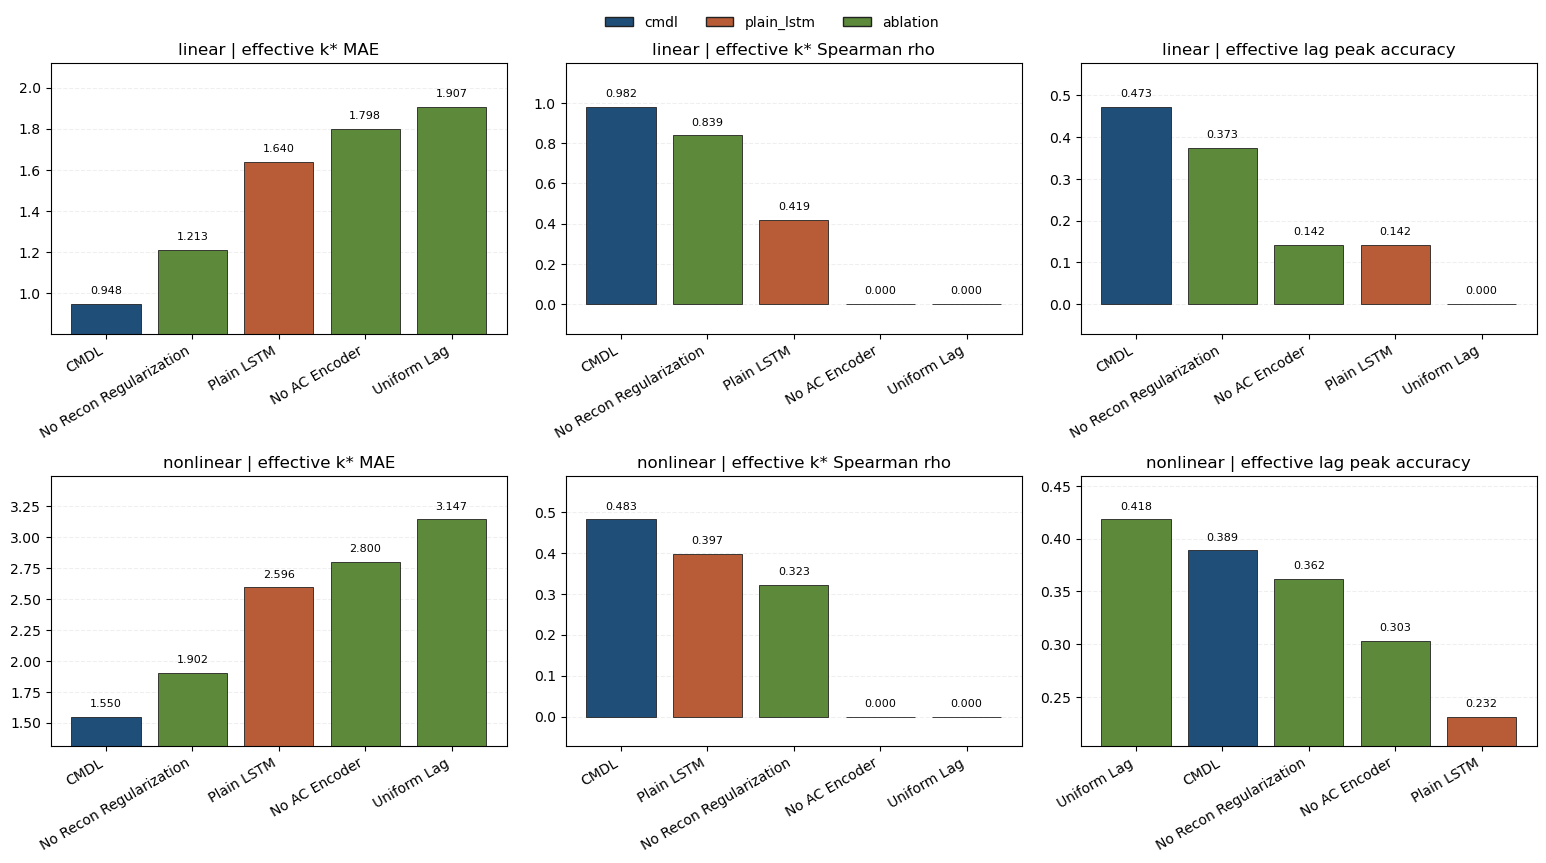

saved -> C:\DevSpace\PyDevspace\CMDL\outputs\notebook_step45\formal_target\comparison_plots\recovery_comparison.png


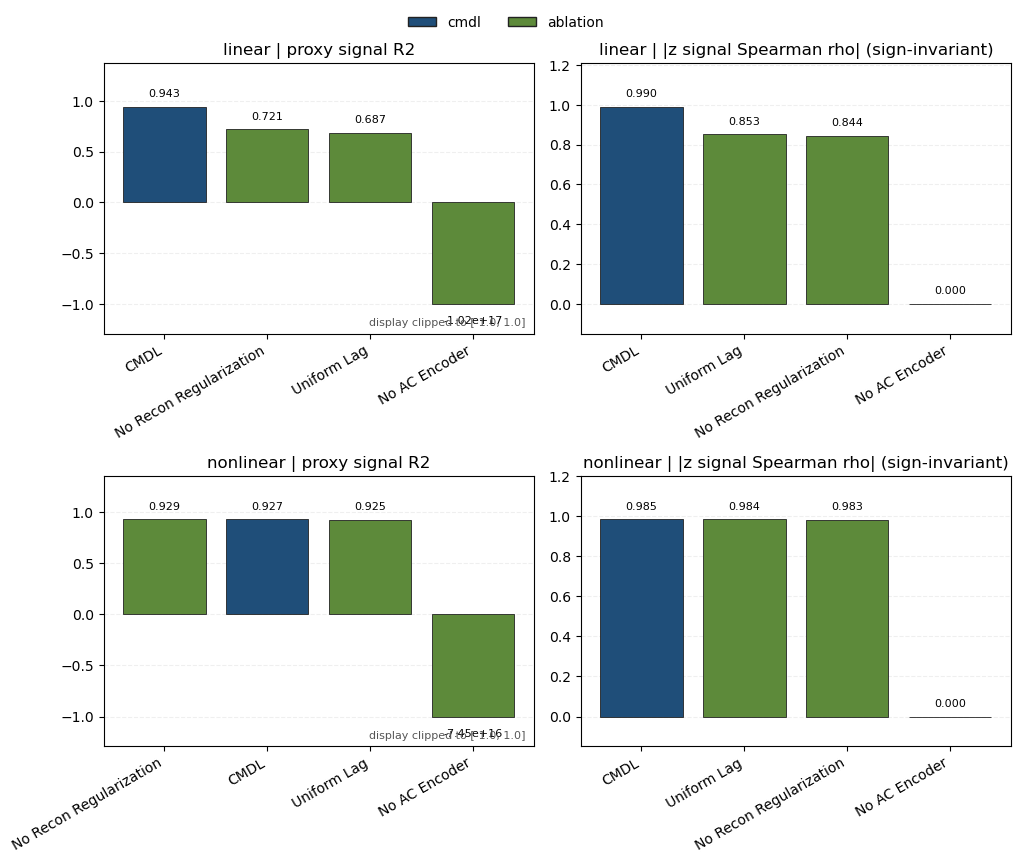

saved -> C:\DevSpace\PyDevspace\CMDL\outputs\notebook_step45\formal_target\comparison_plots\identification_comparison.png


,artifact,path
0,recovery_plot,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_s...
1,identification_plot,C:\DevSpace\PyDevspace\CMDL\outputs\notebook_s...


In [9]:
from matplotlib.patches import Patch

comparison_plot_dir = STEP45_OUTPUT_DIR / "comparison_plots"
comparison_plot_dir.mkdir(parents=True, exist_ok=True)

family_palette = {
    "cmdl": "#1f4e79",
    "plain_lstm": "#b85c38",
    "ablation": "#5d8a3a",
}
# z_signal_spearman_rho 在 evaluation/synthetic_comparison.py 中已取 |ρ|（z 是 sign-invariant 隐变量），
# 因此显示范围收紧到 [0, 1]，与 proxy_signal_r2 / effective_lag_peak_accuracy 等非负识别指标统一。
metric_clip_bounds = {
    "proxy_signal_r2": (-1.0, 1.0),
    "z_signal_spearman_rho": (0.0, 1.0),
    "effective_kstar_spearman_rho": (-1.0, 1.0),
    "effective_lag_peak_accuracy": (0.0, 1.0),
}


def format_metric_value(value: float) -> str:
    if not np.isfinite(value):
        return "nan"
    if abs(value) >= 1e4:
        return f"{value:.2e}"
    return f"{value:.3f}"


def plot_metric_panels(frame: pd.DataFrame, metrics: list[tuple[str, str]], output_name: str) -> Path | None:
    if frame.empty:
        print(f"Skip {output_name}: no rows available. / 跳过 {output_name}：当前没有可绘图的行。")
        return None

    scenarios = [scenario for scenario in ["linear", "nonlinear"] if scenario in frame["scenario"].dropna().unique()]
    if not scenarios:
        scenarios = sorted(frame["scenario"].dropna().unique())

    fig, axes = plt.subplots(
        len(scenarios),
        len(metrics),
        figsize=(5.2 * len(metrics), 4.2 * max(len(scenarios), 1)),
        squeeze=False,
    )

    for row_index, scenario in enumerate(scenarios):
        scenario_frame = frame.loc[frame["scenario"] == scenario].copy()
        for column_index, (metric_key, metric_label) in enumerate(metrics):
            axis = axes[row_index][column_index]
            metric_frame = (
                scenario_frame.loc[:, ["display_name", "family", "scenario", metric_key]]
                .dropna(subset=[metric_key])
                .groupby(["display_name", "family", "scenario"], as_index=False)[metric_key]
                .mean()
            )
            if metric_frame.empty:
                axis.axis("off")
                continue

            ascending = metric_key in {"task_loss", "effective_kstar_mae"}
            metric_frame = metric_frame.sort_values(metric_key, ascending=ascending).reset_index(drop=True)
            colors = metric_frame["family"].map(family_palette).fillna("#777777")
            x_positions = np.arange(len(metric_frame))

            actual_values = metric_frame[metric_key].to_numpy(dtype=float)
            clip_bounds = metric_clip_bounds.get(metric_key)
            if clip_bounds is None:
                plot_values = actual_values.copy()
            else:
                lower_bound = -np.inf if clip_bounds[0] is None else clip_bounds[0]
                upper_bound = np.inf if clip_bounds[1] is None else clip_bounds[1]
                plot_values = np.clip(actual_values, lower_bound, upper_bound)

            bars = axis.bar(x_positions, plot_values, color=colors, edgecolor="#222222", linewidth=0.6)
            axis.set_xticks(x_positions, metric_frame["display_name"], rotation=30, ha="right")
            axis.set_title(f"{scenario} | {metric_label}")
            axis.grid(axis="y", alpha=0.2, linestyle="--")
            axis.set_axisbelow(True)

            y_min = float(np.nanmin(plot_values))
            y_max = float(np.nanmax(plot_values))
            span = max(y_max - y_min, 1e-3)
            axis.set_ylim(y_min - 0.15 * span, y_max + 0.22 * span)

            for bar, plot_value, actual_value in zip(bars, plot_values, actual_values, strict=True):
                offset = 0.04 * span if plot_value >= 0 else -0.06 * span
                vertical_alignment = "bottom" if plot_value >= 0 else "top"
                axis.text(
                    bar.get_x() + bar.get_width() / 2.0,
                    plot_value + offset,
                    format_metric_value(actual_value),
                    ha="center",
                    va=vertical_alignment,
                    fontsize=8,
                )

            if clip_bounds is not None and not np.allclose(actual_values, plot_values):
                lower_label = "-inf" if clip_bounds[0] is None else f"{clip_bounds[0]:.1f}"
                upper_label = "inf" if clip_bounds[1] is None else f"{clip_bounds[1]:.1f}"
                axis.text(
                    0.98,
                    0.02,
                    f"display clipped to [{lower_label}, {upper_label}]",
                    transform=axis.transAxes,
                    ha="right",
                    va="bottom",
                    fontsize=8,
                    color="#555555",
                )

    handles = [
        Patch(facecolor=color, edgecolor="#222222", label=family)
        for family, color in family_palette.items()
        if family in frame["family"].astype(str).unique()
    ]
    if handles:
        fig.legend(handles=handles, loc="upper center", ncol=len(handles), frameon=False, bbox_to_anchor=(0.5, 1.03))

    fig.tight_layout()
    output_path = comparison_plot_dir / output_name
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    display(fig)
    plt.close(fig)
    print(f"saved -> {output_path}")
    return output_path


recovery_plot_path = plot_metric_panels(
    recovery_comparison_table,
    metrics=[
        ("effective_kstar_mae", "effective k* MAE"),
        ("effective_kstar_spearman_rho", "effective k* Spearman rho"),
        ("effective_lag_peak_accuracy", "effective lag peak accuracy"),
    ],
    output_name="recovery_comparison.png",
)

identification_plot_path = plot_metric_panels(
    identification_comparison_table,
    metrics=[
        ("proxy_signal_r2", "proxy signal R2"),
        ("z_signal_spearman_rho", "|z signal Spearman rho| (sign-invariant)"),
    ],
    output_name="identification_comparison.png",
)

pd.DataFrame(
    {
        "artifact": ["recovery_plot", "identification_plot"],
        "path": [recovery_plot_path, identification_plot_path],
    }
)


# Section 3 Retrospective Diagnostics / 第 3 节 回顾性诊断

This section is no longer trying to explain a current Step 4 failure. Instead, it verifies two retrospective claims:
本节不再用于解释一个"当前仍存在的 Step 4 失败"，而是回顾性验证两个判断：

1. the earlier proxy reconstruction failure was not caused by data impossibility, because z_pred still supports a high-quality linear proxy fit; / 早期 proxy 重构失败不是因为数据不可重构，因为 z_pred 仍支持高质量线性映射；
2. the current post-selection refit closes the gap almost exactly to that linear upper bound. / 当前的评估前重拟合几乎精确补齐了这条线性上限与模型原输出之间的差距。


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from config.cmdl_config import CMDLConfig
from data.synthetic.generate import generate_cmdl_synthetic


# Diagnose whether proxy reconstruction is limited by the data-generator design or by the trained model. / 区分 proxy 重构问题来自数据生成设计还是训练后的模型。
# Use the canonical seed so the regenerated data matches the canonical CMDL run loaded above. / 使用 canonical seed，确保这里重新生成的数据与上面加载的 canonical CMDL 运行对齐。
debug_cfg = CMDLConfig.from_domain("synthetic", scenario="linear", seed=CANONICAL_SEED)
debug_panel = generate_cmdl_synthetic(debug_cfg)

proxy_true_columns = [column for column in linear_predictions.columns if column.startswith("proxy_") and column.endswith("_true")]
proxy_true = linear_predictions[proxy_true_columns].to_numpy()
z_pred = linear_predictions[["z_pred"]].to_numpy()
z_true = linear_predictions[["z_true"]].to_numpy()

best_linear_from_z_true = LinearRegression().fit(z_true, proxy_true).predict(z_true)
best_linear_from_z_pred = LinearRegression().fit(z_pred, proxy_true).predict(z_pred)

proxy_debug_table = pd.DataFrame(
    [
        {
            "diagnostic": "best_linear_proxy_r2_from_z_true",
            "value": r2_score(proxy_true, best_linear_from_z_true, multioutput="uniform_average"),
        },
        {
            "diagnostic": "best_linear_proxy_r2_from_z_pred",
            "value": r2_score(proxy_true, best_linear_from_z_pred, multioutput="uniform_average"),
        },
        {
            "diagnostic": "model_proxy_recon_r2",
            "value": extract_metric(e1b_summary, "proxy_recon_r2"),
        },
    ]
)

# Diagnose whether lagged inputs are highly collinear across lag positions. / 检查不同 lag 的输入是否高度共线。
x_values = debug_panel.X_it.squeeze(-1).detach().cpu().numpy()
lag_series = [
    x_values[:, debug_cfg.max_lag - lag : debug_cfg.seq_length - lag].reshape(-1)
    for lag in range(1, debug_cfg.max_lag + 1)
 ]
lag_corr = np.corrcoef(lag_series)
lag_corr_df = pd.DataFrame(
    lag_corr,
    index=[f"lag_{lag}" for lag in range(1, debug_cfg.max_lag + 1)],
    columns=[f"lag_{lag}" for lag in range(1, debug_cfg.max_lag + 1)],
)
mean_abs_offdiag_corr = (np.abs(lag_corr).sum() - np.abs(np.diag(lag_corr)).sum()) / (lag_corr.size - len(lag_corr))

# Summarize the learned peak locations to confirm mode collapse around a few lags. / 汇总学习到的峰值位置，确认是否塌缩到少数 lag。
linear_peak_counts = linear_predictions["omega_peak"].value_counts().sort_index()
nonlinear_peak_counts = nonlinear_predictions["omega_peak"].value_counts().sort_index() if nonlinear_predictions is not None else pd.Series(dtype=int)

peak_debug_table = pd.DataFrame(
    {
        "linear_peak_count": linear_peak_counts,
        "nonlinear_peak_count": nonlinear_peak_counts,
    }
).fillna(0).astype(int)
peak_debug_table.index.name = "omega_peak"

display(proxy_debug_table)
display(pd.DataFrame([{
    "diagnostic": "mean_abs_offdiag_lag_corr",
    "value": mean_abs_offdiag_corr,
}]))
display(lag_corr_df.round(3))
display(peak_debug_table)

if proxy_debug_table.loc[proxy_debug_table["diagnostic"] == "best_linear_proxy_r2_from_z_true", "value"].item() < 0.5:
    print("Proxy reconstruction ceiling is already low with a linear map from z_true, so the generator/head pair is mismatched.")
    print("即使直接用 z_true 做线性重构，proxy R2 上限也偏低，说明当前生成器与线性重构头存在结构不匹配。")

if mean_abs_offdiag_corr > 0.5:
    print("Lagged inputs are strongly correlated across k, so k* is only weakly identifiable from the task loss alone.")
    print("不同 lag 的输入高度相关，因此仅靠任务损失时，k* 的可识别性会偏弱。")


,diagnostic,value
0,best_linear_proxy_r2_from_z_true,0.943069
1,best_linear_proxy_r2_from_z_pred,0.948505
2,model_proxy_recon_r2,0.948432


,diagnostic,value
0,mean_abs_offdiag_lag_corr,0.314088


,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10
lag_1,1.000,0.655,0.431,0.275,0.177,0.120,0.110,0.094,0.073,0.054
lag_2,0.655,1.000,0.654,0.435,0.284,0.181,0.122,0.110,0.084,0.071
lag_3,0.431,0.654,1.000,0.658,0.440,0.288,0.186,0.129,0.109,0.090
lag_4,0.275,0.435,0.658,1.000,0.656,0.436,0.289,0.188,0.128,0.115
lag_5,0.177,0.284,0.440,0.656,1.000,0.655,0.437,0.293,0.195,0.138
lag_6,0.120,0.181,0.288,0.436,0.655,1.000,0.654,0.435,0.294,0.201
lag_7,0.110,0.122,0.186,0.289,0.437,0.654,1.000,0.657,0.442,0.301
lag_8,0.094,0.110,0.129,0.188,0.293,0.435,0.657,1.000,0.664,0.453
lag_9,0.073,0.084,0.109,0.128,0.195,0.294,0.442,0.664,1.000,0.669
lag_10,0.054,0.071,0.090,0.115,0.138,0.201,0.301,0.453,0.669,1.000


,linear_peak_count,nonlinear_peak_count
omega_peak,,
1,0,137
4,83,0
6,49,0
7,23,24
8,45,0
9,0,39


## Historical Sweep / 历史配置回看

This sweep reruns the historical hyperparameter settings under the current code path to compare k* recovery behavior.
本节在当前代码路径下重跑历史超参配置，用于比较 k* 恢复行为。

Important note: because the proxy head is now refit after best-checkpoint selection, the proxy_recon_r2 values below should be read as the recoverability of proxy information from the learned z representation, not as the training-time convergence quality of the original reconstructor.
注意：由于当前流程会在 best checkpoint 选出后重拟合 proxy head，下表中的 proxy_recon_r2 应理解为“学到的 z 对 proxy 信息的可恢复程度”，而不是“原始训练阶段 reconstructor 的收敛质量”。

In [11]:
from copy import deepcopy

debug_output_root = repo_root / "outputs" / "notebook_step4" / "debug_sweeps"
debug_output_root.mkdir(parents=True, exist_ok=True)

debug_configs = [
    {"name": "baseline_60", "epochs": 60, "patience": 15, "lambda_r": 0.1, "temperature": 1.0, "lag_bias_strength": 1.0},
    {"name": "sharp_gate", "epochs": 60, "patience": 15, "lambda_r": 0.1, "temperature": 0.3, "lag_bias_strength": 0.1},
    {"name": "recon_focus", "epochs": 60, "patience": 15, "lambda_r": 1.0, "temperature": 1.0, "lag_bias_strength": 1.0},
    {"name": "combined", "epochs": 60, "patience": 15, "lambda_r": 1.0, "temperature": 0.3, "lag_bias_strength": 0.1},
]

debug_rows = []
for config in debug_configs:
    debug_args_dict = deepcopy(COMMON_ARGS)
    debug_args_dict.update(
        {
            "scenario": "linear",
            "epochs": config["epochs"],
            "patience": config["patience"],
            "lambda_r": config["lambda_r"],
            "temperature": config["temperature"],
            "lag_bias_strength": config["lag_bias_strength"],
            "log_every": 20,
            "output_dir": str(debug_output_root / config["name"]),
        }
    )
    debug_args = Namespace(**debug_args_dict)
    debug_linear_result = run_e1a(debug_args)
    debug_e1b_summary = run_e1b(debug_args, debug_linear_result)
    debug_predictions = pd.read_csv(Path(debug_args.output_dir) / "E1a_linear" / "predictions.csv")

    debug_rows.append(
        {
            "name": config["name"],
            "epochs": config["epochs"],
            "lambda_r": config["lambda_r"],
            "temperature": config["temperature"],
            "lag_bias_strength": config["lag_bias_strength"],
            "kstar_mae": debug_linear_result.metrics["kstar_mae"],
            "kstar_spearman_rho": debug_linear_result.metrics["kstar_spearman_rho"],
            "omega_peak_accuracy": debug_linear_result.metrics["omega_peak_accuracy"],
            "omega_entropy_mean": debug_linear_result.metrics["omega_entropy_mean"],
            "proxy_recon_r2": debug_e1b_summary["metrics"]["proxy_recon_r2"],
            "z_spearman_rho": debug_e1b_summary["metrics"]["z_spearman_rho"],
            "unique_omega_peaks": int(debug_predictions["omega_peak"].nunique()),
            "min_omega_peak": int(debug_predictions["omega_peak"].min()),
            "max_omega_peak": int(debug_predictions["omega_peak"].max()),
        }
    )

debug_sweep_table = pd.DataFrame(debug_rows).sort_values(["kstar_mae", "proxy_recon_r2"], ascending=[True, False])
display(debug_sweep_table)

[E1a_linear] epoch=001 train_total=0.6011 val_task=0.4842 val_kstar_mae=2.0237 val_proxy_r2=-4.0013
[E1a_linear] epoch=020 train_total=0.1140 val_task=0.0948 val_kstar_mae=1.9609 val_proxy_r2=-4.9373
[E1a_linear] epoch=040 train_total=0.1065 val_task=0.0794 val_kstar_mae=1.8307 val_proxy_r2=-5.3416
[E1a_linear] epoch=060 train_total=0.0975 val_task=0.0723 val_kstar_mae=1.4887 val_proxy_r2=-5.8615
[E1a_linear] epoch=001 train_total=0.6040 val_task=0.4824 val_kstar_mae=1.7508 val_proxy_r2=-4.0017
[E1a_linear] epoch=020 train_total=0.1117 val_task=0.0993 val_kstar_mae=1.7227 val_proxy_r2=-4.5698
[E1a_linear] epoch=040 train_total=0.0965 val_task=0.0807 val_kstar_mae=1.3878 val_proxy_r2=-4.2924
[E1a_linear] epoch=060 train_total=0.0847 val_task=0.0799 val_kstar_mae=1.2165 val_proxy_r2=-4.0978
[E1a_linear] epoch=001 train_total=0.9410 val_task=0.4842 val_kstar_mae=2.0237 val_proxy_r2=-4.0013
[E1a_linear] epoch=020 train_total=0.5035 val_task=0.0955 val_kstar_mae=1.9610 val_proxy_r2=-4.9249


,name,epochs,lambda_r,temperature,lag_bias_strength,kstar_mae,kstar_spearman_rho,omega_peak_accuracy,omega_entropy_mean,proxy_recon_r2,z_spearman_rho,unique_omega_peaks,min_omega_peak,max_omega_peak
3,combined,60,1.0,0.3,0.1,1.191315,0.980962,0.295,1.369975,0.952389,-0.989782,2,4,8
1,sharp_gate,60,0.1,0.3,0.1,1.191824,0.981006,0.295,1.372278,0.952366,-0.989783,2,4,8
2,recon_focus,60,1.0,1.0,1.0,1.439087,0.980781,0.295,1.885184,0.950745,-0.989626,2,4,8
0,baseline_60,60,0.1,1.0,1.0,1.443431,0.980785,0.295,1.887424,0.950754,-0.989663,2,4,8


<Figure size 900x1050 with 0 Axes>

<Figure size 700x600 with 0 Axes>

<Figure size 900x1050 with 0 Axes>

<Figure size 700x600 with 0 Axes>

<Figure size 900x1050 with 0 Axes>

<Figure size 700x600 with 0 Axes>

<Figure size 900x1050 with 0 Axes>

<Figure size 700x600 with 0 Axes>